# Video Processing and Object Tracking

## Background Substraction Methods

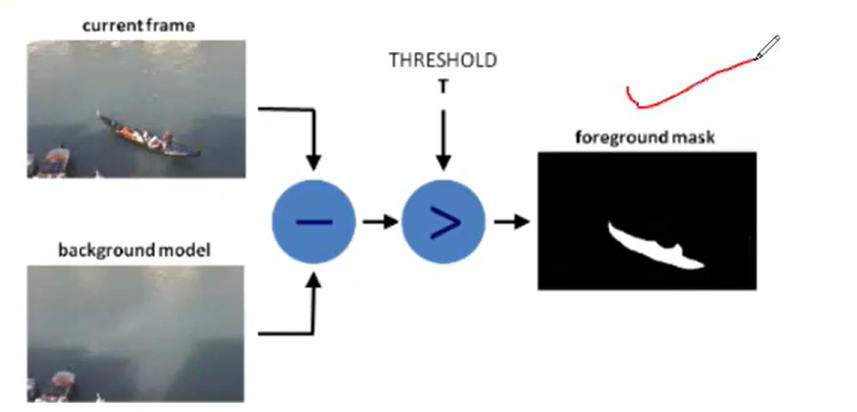

In [4]:
import cv2

source = cv2.VideoCapture('../Samples/bikes.mp4')
background_subtractor = cv2.createBackgroundSubtractorMOG2()

while True:
    ret, img = source.read()
    # img=cv2.resize(img, (500,500))
    img = cv2.resize(img, (0,0), fx=0.5, fy=0.5)

    fgmask = background_subtractor.apply(img)

    cv2.imshow('Original', img)
    cv2.imshow('Foreground Mask', fgmask)
    key = cv2.waitKey(10)
    if key == 27:
        break

cv2.destroyAllWindows()
source.release()


## Mean Shift

In [2]:
import cv2
import numpy as np

source = cv2.VideoCapture(0)

x,y,w,h = 0,0,100,50
track_window = (x,y,w,h)

ret, img = source.read()

roi = img[y:y+h, x:x+w]
hsv_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)

mask = cv2.inRange(hsv_roi, np.array((0,80,88)), np.array((5,255,255)))

roi_hist = cv2.calcHist([hsv_roi], [0], mask, [256], [0,256])
cv2.normalize(roi_hist, roi_hist, 0, 255, cv2.NORM_MINMAX)

term_crit = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 1)

while True:
    ret, img = source.read()

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    dst = cv2.calcBackProject([hsv], [0], roi_hist, [0,256], 1)

    ret, track_window = cv2.meanShift(dst, track_window, term_crit)

    x,y,w,h = track_window
    img2 = cv2.rectangle(img, (x,y), (x+w,y+h), 255, 3)

    cv2.imshow('Tracking', img2)
    key = cv2.waitKey(10)
    if key == 27:
        break

cv2.destroyAllWindows()

## Object Detection using Haarcascade Classifiers

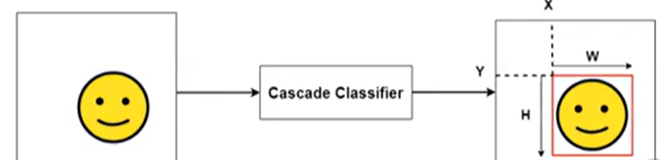

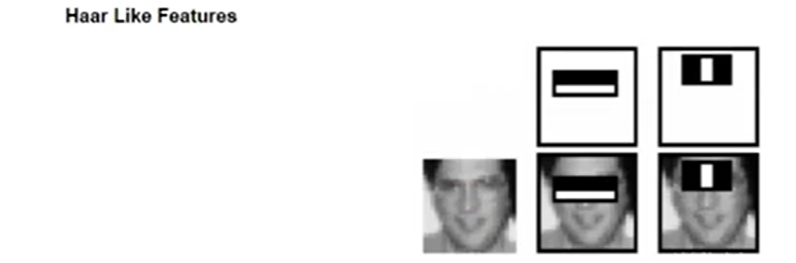

This classifier can detect one object type at a time

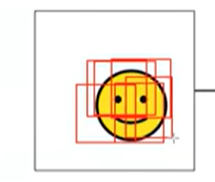

### Face Detection using Python and OpenCV

In [11]:
%pip uninstall opencv-python opencv-contrib-python opencv-python-headless -y


Found existing installation: opencv-python 5.0.0.93
Uninstalling opencv-python-5.0.0.93:
  Successfully uninstalled opencv-python-5.0.0.93
Note: you may need to restart the kernel to use updated packages.


In [12]:
%pip install opencv-python==4.10.0.84

   ---------------------------------------- 0.0/38.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.8 MB ? eta -:--:--
    --------------------------------------- 0.8/38.8 MB 1.1 MB/s eta 0:00:35
    --------------------------------------- 0.8/38.8 MB 1.1 MB/s eta 0:00:35
   - -------------------------------------- 1.0/38.8 MB 1.1 MB/s eta 0:00:35
   - -------------------------------------- 1.3/38.8 MB 1.0 MB/s eta 0:00:38
   - -------------------------------------- 1.6/38.8 MB 994.1 kB/s eta 0:00:38
   - -------------------------------------- 1.6/38.8 MB 994.1 kB/s eta 0:00:38
   - -------------------------------------- 1.6/38.8 MB 994.1 kB/s eta 0:00:38
   - -------------------------------------- 1.6/38.8 MB 994.1 kB/s eta 0:00:38
   - -------------------------------------- 1.8/38.8 MB 808.8 kB/s eta 0:00:46
   - ------------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import cv2

print(cv2.__version__)
print(hasattr(cv2, "CascadeClassifier"))

4.10.0
True


In [ ]:
import cv2

img = cv2.imread('../Samples/multi-faces.png')
img = cv2.resize(img, (0,0), fx=0.5, fy=0.5)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

face_classifier = cv2.CascadeClassifier(r'C:\courses\OpenCV\My Practice\Cascades\Face & Eyes\haarcascade_frontalface_default.xml')

faces = face_classifier.detectMultiScale(gray)

for face in faces:
    print(face)
    x = face[0]
    y = face[1]
    w = face[2]
    h = face[3]

    cv2.rectangle(img,(x,y), (x+w, y+h), (0,255,0), 2)

cv2.imshow('Original', img)
key = cv2.waitKey(0)
cv2.destroyAllWindows()

[ 35  42 130 130]
[425  33 145 145]
[237 244 130 130]
[ 25 233 147 147]
[426 236 143 143]
[225  37 142 142]


x y w h

face1

face2

face3

face4

face5

face6

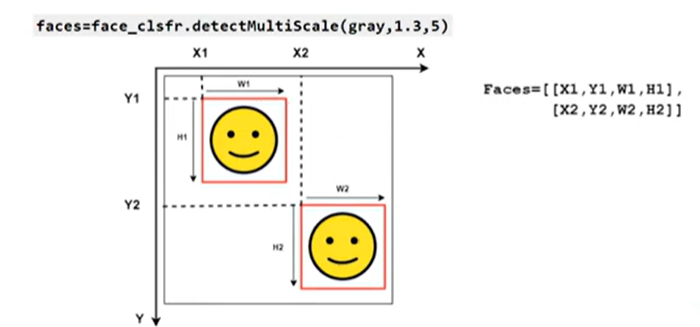